# Bank Customer Churn Analysis

## Business context
A retention analyst at a retail bank wants to understand two things: (1) which
customer segments are leaving, and what distinguishes them, and (2) which factors
most strongly predict churn when .controlling for the others, so the bank can target 
retention effort where it matters.

## Questions
1. Which customer segments are most likely to churn, and what are they doing differently?
2. What factors most strongly predict churn, holding other factors constant?

## Tools
- Python 3.12, pandas, numpy
- sqlite3 (in-memory SQL for the segmentation)
- matplotlib, seaborn

## Loading and inspecting the data

Before the SQL segmentation, the data is loaded and checked in pandas: shape and
column types, an integrity pass for nulls and duplicate IDs, summary statistics,
and the overall churn rate that every segment below is compared against.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling (applied once for the whole notebook)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('data/Churn_Modelling.csv')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (10000, 14)
Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
df.info()
print("\nTotal nulls:", df.isnull().sum().sum())
print("Duplicate CustomerIds:", df['CustomerId'].duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB

Total nulls: 0
Duplicate CustomerIds: 0


In [3]:
display(df.describe())

churn_rate = df['Exited'].mean()
print(f"\nOverall churn rate: {churn_rate:.1%}")
print(df['Exited'].value_counts())

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000



Overall churn rate: 20.4%
Exited
0    7963
1    2037
Name: count, dtype: int64


## Setting up SQL

The descriptive segmentation below is done in SQL. We load the dataset into an
in-memory SQLite database and query it directly, pulling results into pandas only to chart them. This mirrors how analysis is split in practice: SQL to aggregate,
Python to visualize.

In [4]:
import sqlite3

# In-memory SQLite DB; the connection stays alive for the rest of the notebook
conn = sqlite3.connect(':memory:')
df.to_sql('customers', conn, index=False, if_exists='replace')

# Confirm the table loaded
pd.read_sql_query("SELECT COUNT(*) AS n_rows FROM customers", conn)

,n_rows
0,10000


## Segmentation: which customer segments churn?

This section answers the first question: which customer segments are most likely to
churn, and what distinguishes them. Each cut compares a segment's churn rate against
the 20.4% overall baseline, reading the rate alongside the number of customers it
rests on. The factors are taken one at a time, then combined into a single high-risk
profile at the end.

### Churn by geography

The first segment cut. `AVG(Exited)` is the churn rate (the mean of a 0/1 column is the proportion of 1s), so it reads as cleanly in SQL as `.mean()` does in pandas.

In [5]:
query = """
SELECT
    Geography,
    COUNT(*)                     AS n_customers,
    SUM(Exited)                  AS n_churned,
    ROUND(AVG(Exited) * 100, 1)  AS churn_rate_pct
FROM customers
GROUP BY Geography
ORDER BY churn_rate_pct DESC
"""
geo_churn = pd.read_sql_query(query, conn)
geo_churn

,Geography,n_customers,n_churned,churn_rate_pct
0,Germany,2509,814,32.4
1,Spain,2477,413,16.7
2,France,5014,810,16.2


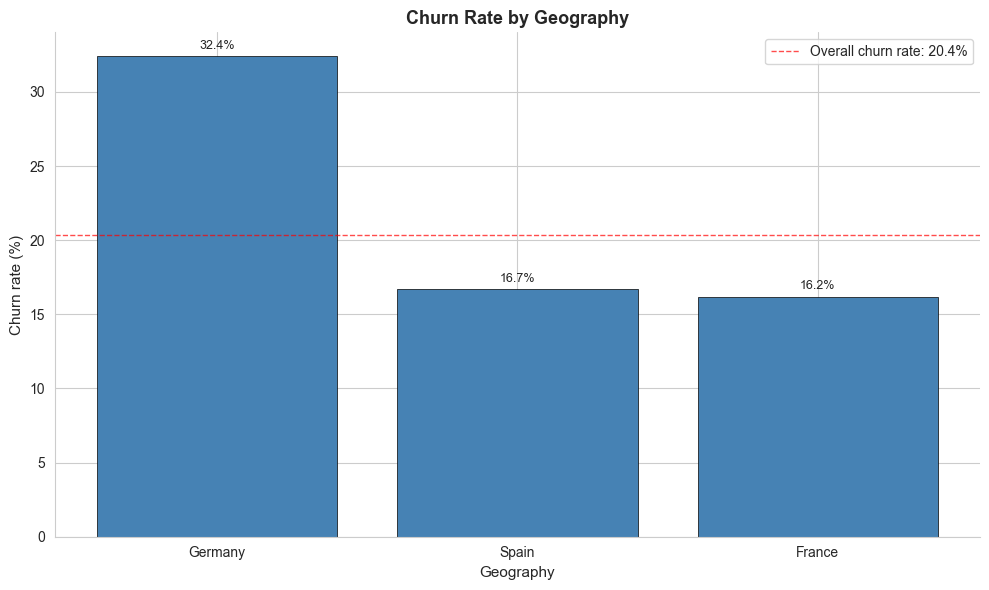

In [6]:
baseline = df['Exited'].mean() * 100

fig, ax = plt.subplots()
bars = ax.bar(geo_churn['Geography'], geo_churn['churn_rate_pct'],
              color='steelblue', edgecolor='black', linewidth=0.5)

ax.axhline(baseline, color='red', linestyle='--', linewidth=1, alpha=0.7,
           label=f'Overall churn rate: {baseline:.1f}%')

ax.set_xlabel('Geography', fontsize=11)
ax.set_ylabel('Churn rate (%)', fontsize=11)
ax.set_title('Churn Rate by Geography', fontsize=13, fontweight='bold')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.3,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

**German customers leave at roughly twice the rate of other markets.**

Germany is 25% of the customer base (2,509 of 10,000) but accounts for 40% of all losses. Germany churns at 32.4%, against 16.7% in Spain and 16.2% in France, roughly double either and the only market above the 20.4% baseline.

Each euro spent retaining a German customer prevents more churn than the same euro spread evenly across all three markets.

**Caveat**
Germany's higher churn could partly reflect other things German customers have in common, for instance older age, higher balances, or a different product mix, rather than anything about the country itself. The regression model in `02_modeling.ipynb` will test whether geography predicts churn independently, once those other factors are held constant.

### Churn by age

The second cut. Age is grouped into bands with a SQL CASE expression rather than
queried per individual year, since per-year rates would be noisy and the band view
makes the trend readable. Bucketing a continuous variable with CASE WHEN is a
standard SQL technique for turning a numeric column into interpretable groups.

In [7]:
query = """
SELECT
    CASE
        WHEN Age < 30 THEN '18-29'
        WHEN Age < 40 THEN '30-39'
        WHEN Age < 50 THEN '40-49'
        WHEN Age < 60 THEN '50-59'
        ELSE '60+'
    END                          AS age_band,
    COUNT(*)                     AS n_customers,
    SUM(Exited)                  AS n_churned,
    ROUND(AVG(Exited) * 100, 1)  AS churn_rate_pct
FROM customers
GROUP BY age_band
ORDER BY MIN(Age)
"""
age_churn = pd.read_sql_query(query, conn)
age_churn

,age_band,n_customers,n_churned,churn_rate_pct
0,18-29,1641,124,7.6
1,30-39,4346,473,10.9
2,40-49,2618,806,30.8
3,50-59,869,487,56.0
4,60+,526,147,27.9


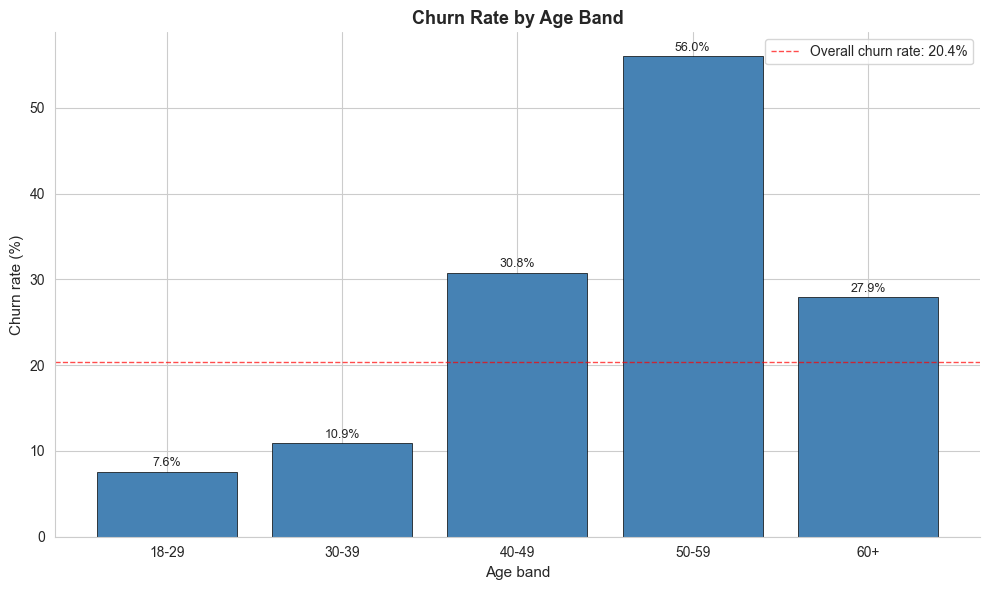

In [8]:
baseline = df['Exited'].mean() * 100

fig, ax = plt.subplots()
bars = ax.bar(age_churn['age_band'], age_churn['churn_rate_pct'],
              color='steelblue', edgecolor='black', linewidth=0.5)

ax.axhline(baseline, color='red', linestyle='--', linewidth=1, alpha=0.7,
           label=f'Overall churn rate: {baseline:.1f}%')

ax.set_xlabel('Age band', fontsize=11)
ax.set_ylabel('Churn rate (%)', fontsize=11)
ax.set_title('Churn Rate by Age Band', fontsize=13, fontweight='bold')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.3,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

**Churn rises steeply with age to a peak in the fifties, then eases.**

Churn climbs steeply with age, from 7.6% in the under-thirties to a 56% peak in the fifties, then falls back at 60+. The 50-59 band has the highest rate but only 487 churners, because the band is small. The 40-49 band has a lower rate yet produces 806 churners, the most of any band, because it is far larger. Together these two cohorts are about a third of all customers but produce roughly two-thirds of all churn.

Retention effort should prioritize the 40-49 band first, since it combines a high rate with the largest volume and so reaches the most at-risk customers, followed by 50-59 for the severity of its rate.

**Caveat**

The 60+ band lumps everyone from 60 to 92 into one group and holds a small share of customers, so the drop is best read as churn levelling off rather than a precise estimate.

### Churn by number of products

The third cut. NumOfProducts is already a discrete count (1 to 4), so unlike the
age cut it needs no bucketing; we group on the column directly.

In [9]:
query = """
SELECT
    NumOfProducts,
    COUNT(*)                     AS n_customers,
    SUM(Exited)                  AS n_churned,
    ROUND(AVG(Exited) * 100, 1)  AS churn_rate_pct
FROM customers
GROUP BY NumOfProducts
ORDER BY NumOfProducts
"""
products_churn = pd.read_sql_query(query, conn)
products_churn

,NumOfProducts,n_customers,n_churned,churn_rate_pct
0,1,5084,1409,27.7
1,2,4590,348,7.6
2,3,266,220,82.7
3,4,60,60,100.0


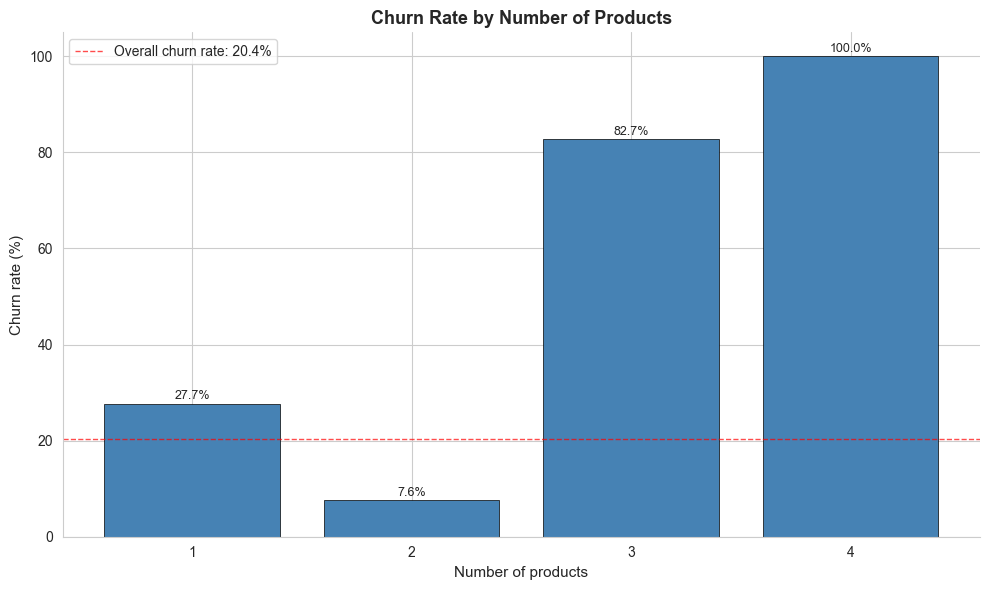

In [10]:
baseline = df['Exited'].mean() * 100

fig, ax = plt.subplots()
bars = ax.bar(products_churn['NumOfProducts'].astype(str), products_churn['churn_rate_pct'],
              color='steelblue', edgecolor='black', linewidth=0.5)

ax.axhline(baseline, color='red', linestyle='--', linewidth=1, alpha=0.7,
           label=f'Overall churn rate: {baseline:.1f}%')

ax.set_xlabel('Number of products', fontsize=11)
ax.set_ylabel('Churn rate (%)', fontsize=11)
ax.set_title('Churn Rate by Number of Products', fontsize=13, fontweight='bold')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.3,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

**Churn is lowest among two-product customers, while one-product customers drive most churn volume.**

Churn varies sharply by number of products. Two-product customers are the stickiest group in this cut, with a churn rate of only 7.6%, well below the overall baseline of 20.4%. One-product customers churn at a higher rate of 27.7%, while three- and four-product customers show extreme churn rates of 82.7% and 100.0%, respectively.

However, the rate pattern and the business volume point to different priorities. The three- and four-product groups contain only 266 and 60 customers, or about 3% of the customer base combined. Their churn rates are therefore important warning signs, but they account for only 280 churners in total, about 14% of all churned customers. By contrast, one-product customers make up roughly half of the customer base and account for 1,409 churners, or about 69% of all churn in the dataset.

The practical takeaway is that one-product customers are the largest retention opportunity by volume, while the three- and four-product groups deserve separate investigation because their churn rates are unusually high. A natural hypothesis is that moving suitable one-product customers toward a second product could improve retention, but this should be tested rather than assumed. The low churn among two-product customers may reflect differences in customer profile or engagement, not necessarily a causal effect of holding exactly two products.

**Caveats**

* The three- and four-product churn rates are based on small groups, especially the four-product group with only 60 customers. The 100% churn rate should therefore be treated as a strong directional signal and investigated further, not interpreted as a precise, stable estimate.
* This analysis shows an association between product count and churn. It does not prove that changing a customer’s number of products would directly change their churn behavior.


### Churn by balance

The fourth cut. Balance is continuous, so it is grouped into bands with a CASE
expression, as with age. Customers with a zero balance are kept as their own band
rather than merged into the lowest bucket, since a zero balance is a distinct and
meaningful state rather than simply a low value.

In [11]:
query = """
SELECT
    CASE
        WHEN Balance = 0 THEN '0 (zero)'
        WHEN Balance < 50000 THEN '1-50k'
        WHEN Balance < 100000 THEN '50k-100k'
        WHEN Balance < 150000 THEN '100k-150k'
        ELSE '150k+'
    END                          AS balance_band,
    COUNT(*)                     AS n_customers,
    SUM(Exited)                  AS n_churned,
    ROUND(AVG(Exited) * 100, 1)  AS churn_rate_pct
FROM customers
GROUP BY balance_band
ORDER BY MIN(Balance)
"""
balance_churn = pd.read_sql_query(query, conn)
balance_churn

,balance_band,n_customers,n_churned,churn_rate_pct
0,0 (zero),3617,500,13.8
1,1-50k,75,26,34.7
2,50k-100k,1509,300,19.9
3,100k-150k,3830,987,25.8
4,150k+,969,224,23.1


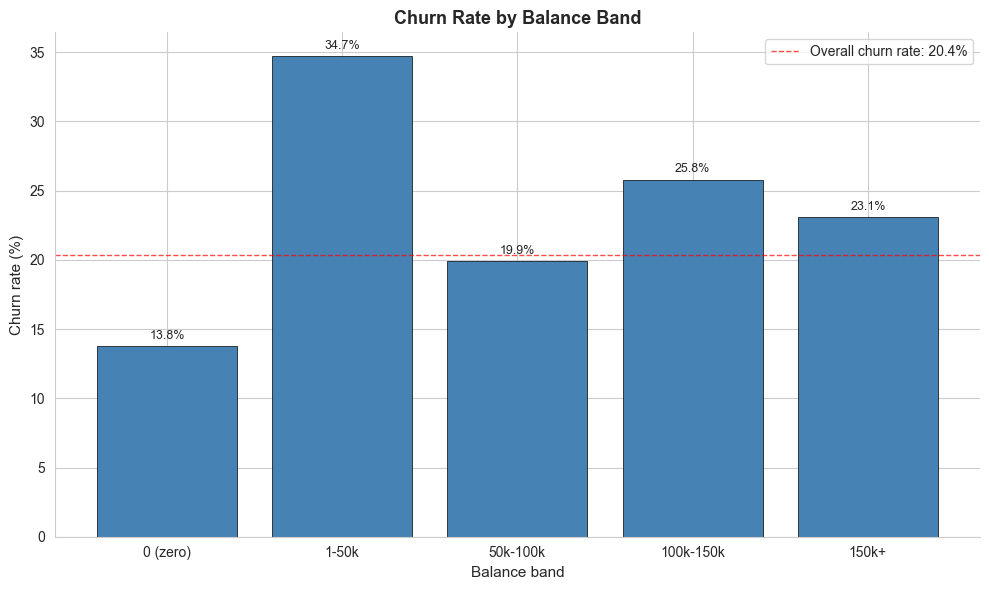

In [12]:
baseline = df['Exited'].mean() * 100

fig, ax = plt.subplots()
bars = ax.bar(balance_churn['balance_band'], balance_churn['churn_rate_pct'],
              color='steelblue', edgecolor='black', linewidth=0.5)

ax.axhline(baseline, color='red', linestyle='--', linewidth=1, alpha=0.7,
           label=f'Overall churn rate: {baseline:.1f}%')

ax.set_xlabel('Balance band', fontsize=11)
ax.set_ylabel('Churn rate (%)', fontsize=11)
ax.set_title('Churn Rate by Balance Band', fontsize=13, fontweight='bold')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.3,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend()
plt.tight_layout()
plt.show()

**Zero-balance customers churn less than average, while the largest churn volume sits in the 100k–150k balance band.**

Churn does not increase smoothly with balance. Customers with a zero balance have the lowest churn rate in this cut at 13.8%, well below the overall baseline of 20.4%. Among funded customers, churn ranges from roughly 20% to 26% without a clean upward climb: the 50k–100k band is close to baseline at 19.9%, the 100k–150k band rises to 25.8%, and the 150k+ band falls slightly to 23.1%. The 1–50k band has the highest observed churn rate at 34.7%, but it contains only 75 customers, so it should be treated as a small-sample warning rather than the main pattern.

By volume, the 100k–150k band is the most important balance segment. It contains 3,830 customers and produces 987 churners, the most of any balance band and about 48% of all churn in the dataset. Zero-balance customers are also a major contributor by volume: despite their below-average churn rate, they produce 500 churners, about a quarter of all churn, because they are such a large group. This shows why both rate and volume matter: the highest-risk small group is not necessarily the biggest business problem, and a lower-risk large group can still create substantial losses.

The practical takeaway is that the 100k–150k balance band deserves close retention attention because it combines above-average churn, large customer volume, and higher likely business value per lost customer than empty-account churn. Losing a high-balance customer is likely more costly to the bank than losing a zero-balance customer, so balance matters not only as a churn segment but also as a proxy for potential revenue exposure.

**Caveats**

* The 1–50k band has the highest churn rate, but it is based on only 75 customers. Its 34.7% rate should be interpreted cautiously and investigated further rather than treated as a stable estimate.
* Balance is associated with churn in this descriptive cut, but it may also be acting as a proxy for other customer differences such as geography, age, activity, or product mix. The modeling section should test whether balance still matters after controlling for those factors.



### Churn by activity status

The fifth cut. IsActiveMember is already a binary flag (0 or 1), so like the
products cut it needs no bucketing; we group on it directly and relabel the two
values for readability.

In [13]:
query = """
SELECT
    CASE IsActiveMember
        WHEN 1 THEN 'Active'
        ELSE 'Inactive'
    END                          AS activity_status,
    COUNT(*)                     AS n_customers,
    SUM(Exited)                  AS n_churned,
    ROUND(AVG(Exited) * 100, 1)  AS churn_rate_pct
FROM customers
GROUP BY activity_status
ORDER BY churn_rate_pct DESC
"""
activity_churn = pd.read_sql_query(query, conn)
activity_churn

,activity_status,n_customers,n_churned,churn_rate_pct
0,Inactive,4849,1302,26.9
1,Active,5151,735,14.3


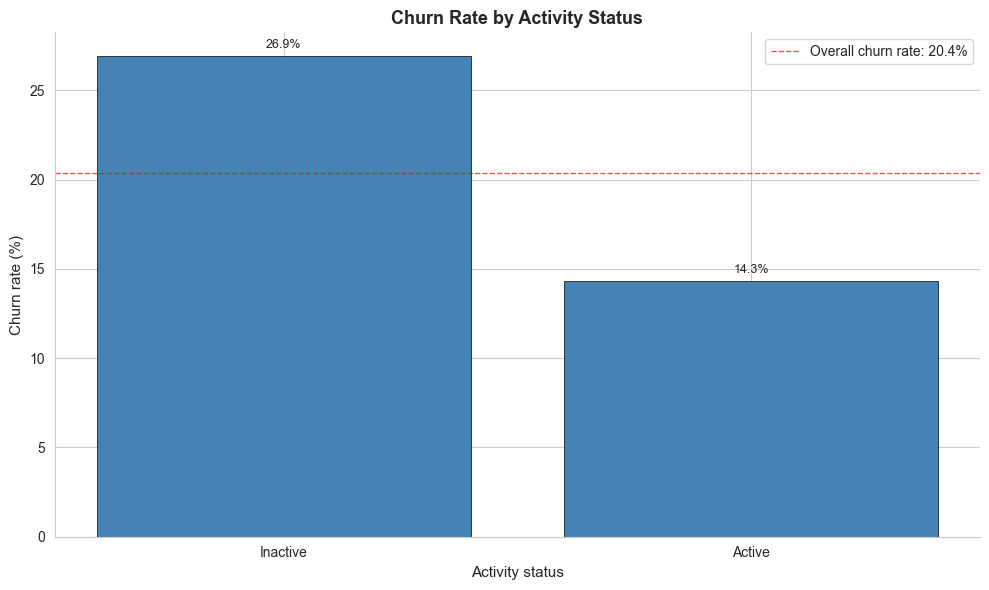

In [14]:
baseline = df['Exited'].mean() * 100

fig, ax = plt.subplots()
bars = ax.bar(activity_churn['activity_status'], activity_churn['churn_rate_pct'],
              color='steelblue', edgecolor='black', linewidth=0.5)

ax.axhline(baseline, color='red', linestyle='--', linewidth=1, alpha=0.7,
           label=f'Overall churn rate: {baseline:.1f}%')

ax.set_xlabel('Activity status', fontsize=11)
ax.set_ylabel('Churn rate (%)', fontsize=11)
ax.set_title('Churn Rate by Activity Status', fontsize=13, fontweight='bold')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.3,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

**Inactive customers churn at roughly double the rate of active customers and account for most churn volume.**

Activity status is one of the clearest churn splits in the analysis. Inactive customers churn at 26.9%, well above the overall baseline of 20.4%, while active customers churn at only 14.3%. This means inactive customers churn at about 1.9 times the rate of active customers. Unlike some earlier cuts, both groups are large and split the customer base almost evenly, so the difference is not driven by a thin or unstable segment.

The volume pattern points in the same direction as the rate pattern. Inactive customers produce 1,302 of the 2,037 total churners, or about 64% of all churn in the dataset. Active customers, despite being slightly more numerous overall, produce only 735 churners. This makes inactivity one of the cleanest retention priorities in the descriptive analysis: the higher-risk group is also the larger source of actual customer loss.

The practical interpretation depends on what inactivity represents. If inactivity contributes to churn, then re-engagement campaigns may help reduce losses by bringing customers back into regular use. If inactivity is instead an early visible sign that a customer is already disengaging, then the activity flag is valuable as an early-warning trigger for retention outreach. Either way, inactive customers should be treated as a high-priority monitoring and intervention group.

**Caveats**

* This snapshot shows that inactivity is strongly associated with churn, but it does not prove the direction of causality. Inactivity may cause churn, or it may simply appear as part of the churn process before the customer leaves.
* Activity status may interact with other factors such as age, geography, product count, and balance. The modeling section should test whether inactivity remains predictive after controlling for those variables.


### Combined high-risk segment

The final cut, and a synthesis of the previous five. Rather than viewing one factor
at a time, this stacks the strongest and most reliable risk factors found above
(inactivity, German geography, and the 50-59 age peak) to see how churn compounds
when they coincide. The factors with the highest single rates but the thinnest
samples (the 3-4 product groups and the 1-50k balance band) are deliberately left
out, since stacking unreliable factors would compound their unreliability rather
than reveal a trustworthy pattern.

In [15]:
query = """
SELECT
    1 AS sort_order,
    'All customers'                  AS segment,
    COUNT(*)                         AS n_customers,
    SUM(Exited)                      AS n_churned,
    ROUND(AVG(Exited) * 100, 1)      AS churn_rate_pct
FROM customers

UNION ALL

SELECT 2, 'Inactive',
    COUNT(*), SUM(Exited), ROUND(AVG(Exited) * 100, 1)
FROM customers
WHERE IsActiveMember = 0

UNION ALL

SELECT 3, 'Inactive + German',
    COUNT(*), SUM(Exited), ROUND(AVG(Exited) * 100, 1)
FROM customers
WHERE IsActiveMember = 0 AND Geography = 'Germany'

UNION ALL

SELECT 4, 'Inactive + German + aged 50-59',
    COUNT(*), SUM(Exited), ROUND(AVG(Exited) * 100, 1)
FROM customers
WHERE IsActiveMember = 0 AND Geography = 'Germany' AND Age BETWEEN 50 AND 59

ORDER BY sort_order
"""
combined_churn = pd.read_sql_query(query, conn)
combined_churn

,sort_order,segment,n_customers,n_churned,churn_rate_pct
0,1,All customers,10000,2037,20.4
1,2,Inactive,4849,1302,26.9
2,3,Inactive + German,1261,518,41.1
3,4,Inactive + German + aged 50-59,146,126,86.3


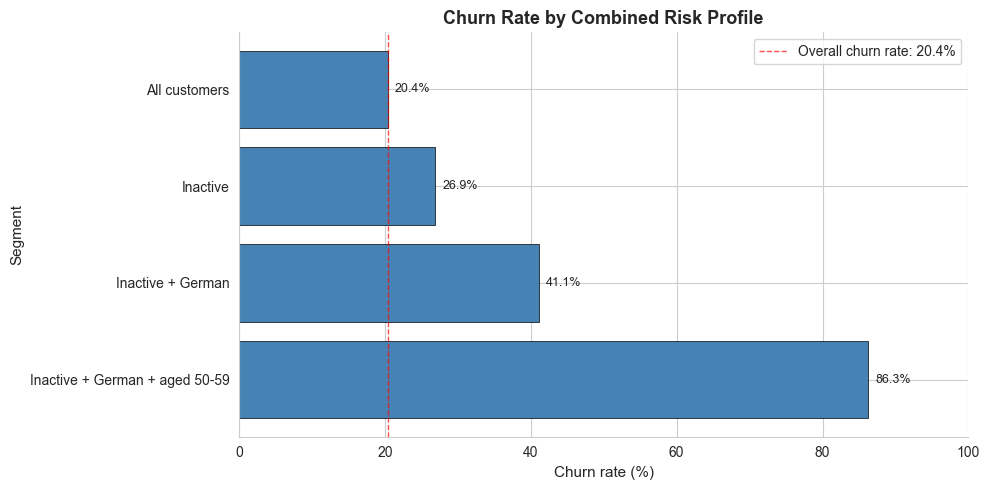

In [16]:
baseline = df['Exited'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(combined_churn['segment'], combined_churn['churn_rate_pct'],
               color='steelblue', edgecolor='black', linewidth=0.5)

ax.axvline(baseline, color='red', linestyle='--', linewidth=1, alpha=0.7,
           label=f'Overall churn rate: {baseline:.1f}%')

ax.set_xlabel('Churn rate (%)', fontsize=11)
ax.set_ylabel('Segment', fontsize=11)
ax.set_title('Churn Rate by Combined Risk Profile', fontsize=13, fontweight='bold')
ax.set_xlim(0, 100)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}%', ha='left', va='center', fontsize=9)

ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

**Churn risk stacks sharply when inactivity, German geography, and middle age coincide.**

The combined-risk profile shows how churn risk concentrates when several high-risk characteristics overlap. Across all customers, the churn rate is 20.4%. Among inactive customers, it rises to 26.9%. Among inactive German customers, it jumps further to 41.1%, based on 1,261 customers. At the narrowest level, inactive German customers aged 50–59 churn at 86.3%, more than four times the overall baseline.

The staircase pattern is the main finding. Each added condition identifies a smaller but higher-risk customer group: 10,000 customers overall, 4,849 inactive customers, 1,261 inactive German customers, and 146 inactive German customers aged 50–59. The inactive German segment is the strongest operational anchor because it is both large enough to support a retention campaign and already churns at roughly double the baseline. The 50–59 subgroup is the extreme tip of the pattern, with 126 of 146 customers churning, but its smaller size means it should be treated as a strong directional signal rather than a precise standalone forecast.

The practical value of this cut is that it turns broad churn drivers into a specific targetable profile. A retention team could directly monitor inactive German customers, then prioritize older customers within that group for deeper review or earlier intervention. The broader inactive German segment may be the more useful campaign target because it combines high risk with meaningful volume, while the inactive German 50–59 segment identifies where risk becomes most concentrated.

**Caveats**

* The 86.3% churn rate for inactive German customers aged 50–59 is based on 146 customers. That is large enough to be meaningful, but still small enough that the exact percentage should be interpreted cautiously.
* This is a descriptive hand-stacked profile, not a controlled model. Inactivity, geography, and age may overlap with other factors such as balance, product count, or gender. The modeling section should test how much each factor contributes after all variables are considered together.


## Conclusions

The clearest churn picture is not that one single attribute explains customer loss, but that risk concentrates where disengagement, market, and life-stage signals overlap. Inactivity is the cleanest behavioral signal, German geography is the strongest market signal, and middle-aged customers show elevated churn with the clearest peak in the fifties. Product count and balance add useful business context, but their patterns are more nuanced: some high-rate groups are small, while some lower-rate groups still create meaningful churn volume because they are large.

For a retention team, the main takeaway is that churn strategy needs two targets rather than one. First, the bank should address broad, reliable volume segments where many losses actually occur, such as inactive customers, one-product customers, and customers in the 100k–150k balance range. These groups matter because they account for substantial customer loss and are large enough to support operational campaigns. Second, the bank should monitor concentrated high-risk pockets, especially inactive German customers and the narrower inactive German 50–59 subgroup. These stacked profiles are smaller, but they show where churn risk becomes most severe and where earlier intervention may be most valuable.

This notebook is descriptive, so the findings should be read as associations rather than proof of causation. The next step is the modeling notebook, which will test these signals together rather than one cut at a time. Logistic regression can show which factors remain predictive after the others are held constant. That is what separates “these groups churn more” from “this factor predicts churn, holding the rest constant.”
